# Prototype-Based Dynamic Persona Steering

Концепция: обобщение persona vectors от Anthropic для копирования характера персонажа через динамическое смещение из распределения кластера прототипа.

**Optimized for Google Colab Pro (L4 GPU)**

In [ ]:
# ==========================================
# 1. SETUP (L4 GPU Optimized)
# ==========================================
import torch
import torch.nn.functional as F
import numpy as np
from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import random
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

if torch.cuda.is_available():
    torch.set_float32_matmul_precision('high')
    torch.backends.cudnn.benchmark = True
    DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Using: {DTYPE}')
else:
    DTYPE = torch.float32

def set_seed(s=42):
    torch.manual_seed(s)
    np.random.seed(s)
    random.seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)
set_seed()

In [ ]:
# Install dependencies (run first in Colab)
!pip install -q transformers accelerate scikit-learn matplotlib tqdm

# Optional: bitsandbytes for 4-bit quantization (uncomment if needed)
# !pip install -q bitsandbytes

## 2. Define Personas

In [ ]:
PERSONAS = {
    'sherlock': {'name': 'Sherlock Holmes', 'traits': ['analytical'],
                 'examples': ['The game is afoot!', 'Elementary, my dear Watson.']},
    'wilde': {'name': 'Oscar Wilde', 'traits': ['witty'],
              'examples': ['I can resist everything except temptation.']},
    'yoda': {'name': 'Yoda', 'traits': ['wise'],
             'examples': ['Do or do not. There is no try.']},
    'pirate': {'name': 'Captain Blackbeard', 'traits': ['rough'],
               'examples': ['Arr matey!', 'Dead men tell no tales.']}
}

def gen_prompts(key, n=50):
    p = PERSONAS[key]
    templates = ['As {name}: {q}', 'You are {name}. {q}']
    queries = ['What do you think?', 'Your opinion?']
    pr = [random.choice(templates).format(name=p['name'], q=random.choice(queries)) for _ in range(n)]
    pr += [f'Example: {e}' for e in p['examples']]
    return pr

data = {k: gen_prompts(k, 80) for k in PERSONAS}
print(f'Generated {len(data)} personas')

## 3. Load Model

In [ ]:
# ==========================================
# 3. LOAD MODEL (Max size for L4 24GB VRAM)
# ==========================================
# L4 24GB VRAM fits:
# - 8B models in bf16 (~16GB) + 4-6GB for activations = ~22GB ✅
# - 14B models in 4-bit (~8GB) but steering works better in full precision
# - 70B models don't fit

MODEL_OPTIONS = {
    '8B-reasoning': 'deepseek-ai/DeepSeek-R1-Distill-Llama-8B',  # Reasoning model!
    '8B-chat': 'meta-llama/Llama-3.1-8B-Instruct',
    '8B': 'meta-llama/Llama-3.1-8B-Instruct',      # ~16GB in bf16, best quality
    '8B-alt': 'meta-llama/Llama-3.3-8B-Instruct',  # Alternative 8B
    '7B': 'mistralai/Mistral-7B-Instruct-v0.3',    # ~14GB, slightly smaller
    '3B': 'meta-llama/Llama-3.2-3B-Instruct',      # ~6GB, for testing
    '14B-4bit': 'Qwen/Qwen2.5-14B-Instruct',       # In 4-bit ~8GB, experimental
}

# RECOMMENDED: 8B model for best steering results
MODEL_KEY = '14B-4bit'
MODEL_NAME = MODEL_OPTIONS[MODEL_KEY]

print(f'Loading: {MODEL_NAME}')
print(f'Estimated VRAM: ~16GB (bf16) + activations')

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Load with optimizations
load_kwargs = {
    'torch_dtype': DTYPE,
    'device_map': 'auto',
    'trust_remote_code': True,
}

# For 14B 4-bit option, uncomment:
# if MODEL_KEY == '14B-4bit':
#     load_kwargs['load_in_4bit'] = True
#     load_kwargs['bnb_4bit_compute_dtype'] = torch.bfloat16

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, **load_kwargs)
model.eval()

# Print VRAM usage
if torch.cuda.is_available():
    vram_mb = torch.cuda.memory_allocated() / 1024**2
    print(f'\n✅ Model loaded!')
    print(f'   Layers: {model.config.num_hidden_layers}')
    print(f'   Hidden size: {model.config.hidden_size}')
    print(f'   VRAM used: {vram_mb:.0f} MB ({vram_mb/1024:.1f} GB)')
    print(f'   VRAM available: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB')

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

## 4. Extract Hidden States

In [ ]:
class Extractor:
    def __init__(self, model, tokenizer):
        self.model, self.tokenizer = model, tokenizer
        n = model.config.num_hidden_layers
        self.layers = [n//4, n//2, 3*n//4, n-1]
        self.states, self.hooks = [], []
        print(f'Layers: {self.layers}')
    
    def _hook(self, idx):
        return lambda m, i, o: self.states[idx].append((o[0] if isinstance(o, tuple) else o)[:, -1].detach().cpu())
    
    def register(self):
        self.states = [[] for _ in self.layers]
        for i, l in enumerate(self.layers):
            layer = self.model.model.layers[l] if hasattr(self.model, 'model') else self.model.transformer.h[l]
            self.hooks.append(layer.register_forward_hook(self._hook(i)))
    
    def remove(self):
        [h.remove() for h in self.hooks]
        self.hooks = []
    
    def extract(self, prompts, bs=8):
        self.register()
        try:
            for i in tqdm(range(0, len(prompts), bs), desc='Extracting'):
                batch = prompts[i:i+bs]
                inp = self.tokenizer(batch, return_tensors='pt', padding=True, truncation=True, max_length=256).to(self.model.device)
                with torch.no_grad():
                    with torch.cuda.amp.autocast(dtype=DTYPE):
                        self.model(**inp)
            return {l: torch.cat(s) for l, s in zip(self.layers, self.states) if s}
        finally:
            self.remove()

extractor = Extractor(model, tokenizer)

In [ ]:
print('Extracting embeddings...')
embs = {}
for k, pr in data.items():
    print(f'\n{k}...')
    embs[k] = extractor.extract(pr, bs=8)
    print(f'  Shape: {list(embs[k].values())[0].shape}')
torch.cuda.empty_cache()

## 5. Prototype Clustering

In [18]:
class Prototype:
    def __init__(self, embs, n_comp=3):
        self.embs = embs.float().numpy()  # Convert bfloat16 to float32 first
        n_s, n_f = self.embs.shape
        self.pca_dim = min(64, n_s//2, n_f)
        if self.pca_dim < n_f:
            self.pca = PCA(self.pca_dim)
            red = self.pca.fit_transform(self.embs)
        else:
            self.pca = None
            red = self.embs
        if n_s >= n_comp * 10:
            self.gmm = GaussianMixture(min(n_comp, n_s//5), covariance_type='full', random_state=42)
            self.gmm.fit(red)
        else:
            self.gmm = None
        self.mean = self.embs.mean(axis=0)
    
    def sample(self, n=1, temp=1.0):
        if self.gmm:
            s, _ = self.gmm.sample(n)
            if temp != 1.0:
                s += np.random.randn(*s.shape) * (temp - 1) * 0.5
            if self.pca:
                s = self.pca.inverse_transform(s)
        else:
            s = np.random.multivariate_normal(self.mean, np.cov(self.embs.T) * temp, n)
        return torch.tensor(s, dtype=torch.float32)
    
    def get_mean(self):
        return torch.tensor(self.mean, dtype=torch.float32)

target_layer = extractor.layers[len(extractor.layers)//2]
prototypes = {k: Prototype(v[target_layer]) for k, v in embs.items()}
print(f'Target layer: {target_layer}')
print('Prototypes created!')

Target layer: 36
Prototypes created!


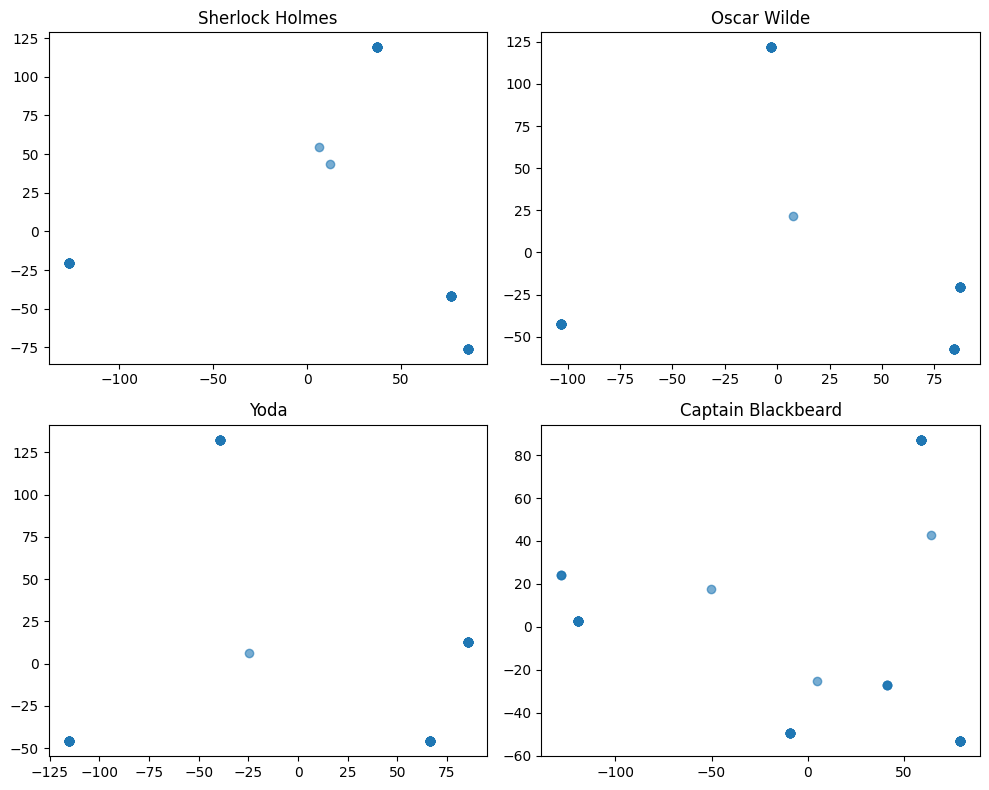

In [19]:
# Visualize
fig, ax = plt.subplots(2, 2, figsize=(10, 8))
ax = ax.flatten()
for i, (k, p) in enumerate(prototypes.items()):
    c = PCA(2).fit_transform(p.embs)
    ax[i].scatter(c[:,0], c[:,1], alpha=0.6)
    ax[i].set_title(PERSONAS[k]['name'])
plt.tight_layout()
plt.savefig('clusters.png')
plt.show()

## 6. Dynamic Steering

In [20]:
class Steerer:
    def __init__(self, model, tokenizer, protos, layer, device):
        self.model, self.tokenizer, self.protos, self.layer, self.device = model, tokenizer, protos, layer, device
        self.v, self.persona, self.strength, self.temp, self.every = None, None, 1.0, 1.0, 1
        self.counter, self.hook, self.debug = 0, None, []
    
    def _hook_fn(self, m, i, o):
        h = o[0] if isinstance(o, tuple) else o
        t = isinstance(o, tuple)
        if self.v is not None:
            if self.counter % self.every == 0:
                self._resample()
            vec = self.v.to(h.device) * self.strength
            h[:, -1] += vec
            if len(self.debug) < 100:
                self.debug.append(vec.cpu().numpy())
            self.counter += 1
        return (h,) + o[1:] if t else h
    
    def _resample(self):
        if self.persona and self.persona in self.protos:
            p = self.protos[self.persona]
            self.v = (p.sample(1, self.temp) - p.get_mean()).squeeze(0)
    
    def set_persona(self, p, strength=1.0, temp=1.0, every=1):
        self.persona, self.strength, self.temp, self.every, self.counter, self.debug = p, strength, temp, every, 0, []
        self._resample()
        print(f'Set: {p}, strength={strength}, temp={temp}')
    
    def register(self):
        layer = self.model.model.layers[self.layer] if hasattr(self.model, 'model') else self.model.transformer.h[self.layer]
        self.hook = layer.register_forward_hook(self._hook_fn)
    
    def remove(self):
        if self.hook:
            self.hook.remove()
            self.hook = None
    
    def generate(self, prompt, max_new=50, temp=0.7, top_p=0.9):
        self.register()
        try:
            inp = self.tokenizer(prompt, return_tensors='pt', padding=True).to(self.device)
            with torch.no_grad(), torch.cuda.amp.autocast(dtype=DTYPE):
                out = self.model.generate(**inp, max_new_tokens=max_new, temperature=temp, top_p=top_p,
                                         do_sample=True, pad_token_id=self.tokenizer.pad_token_id)
            return self.tokenizer.decode(out[0][inp['input_ids'].shape[1]:], skip_special_tokens=True)
        finally:
            self.remove()
            self.counter = 0
    
    def compare(self, prompt, personas=None, **kw):
        personas = personas or list(self.protos.keys())
        r = {'baseline': None}
        self.persona, self.v = None, None
        r['baseline'] = self.generate(prompt, **kw)
        for p in personas:
            self.set_persona(p)
            r[p] = self.generate(prompt, **kw)
        return r

steerer = Steerer(model, tokenizer, prototypes, target_layer, device)
print('Steerer ready!')

Steerer ready!


## 7. Experiments

In [21]:
# Basic comparison
for prompt in ['What is your opinion on technology?', 'Tell me your philosophy.']:
    print(f'\n=== {prompt} ===')
    r = steerer.compare(prompt, ['sherlock', 'wilde', 'yoda'], max_new=40)
    print(f'Baseline: {r["baseline"]}')
    for p in ['sherlock', 'wilde', 'yoda']:
        print(f'{PERSONAS[p]["name"]}: {r[p]}')


=== What is your opinion on technology? ===
Set: sherlock, strength=1.0, temp=1.0
Set: wilde, strength=1.0, temp=1.0
Set: yoda, strength=1.0, temp=1.0
Baseline:  As an AI language model, I don't have personal opinions or feelings, but I can provide an objective view on technology.

Technology has brought numerous benefits to society, including improved communication, increased access to
Sherlock Holmes:  Is it beneficial or harmful to society?
Technology is a tool that can be used for good or bad, and its impact on society is often a matter of perspective. 

On the one hand, technology
Oscar Wilde:  Is it a good thing or does it bring more harm than good?
Technology has both positive and negative aspects, and whether it brings more benefits or harms depends on how it is used and the specific context
Yoda:  Technology has revolutionized many aspects of our lives and has brought about significant changes in how we communicate, work, and entertain ourselves. It has enabled us to do thing

In [22]:
# Temperature effect
print('=== Temperature ===')
for t in [0.5, 1.0, 1.5]:
    print(f'\nTemp: {t}')
    steerer.set_persona('wilde', temp=t, strength=1.2)
    for i in range(2):
        print(f'  {i+1}: {steerer.generate("Thoughts on creativity?", max_new=35)[:70]}...')

=== Temperature ===

Temp: 0.5
Set: wilde, strength=1.2, temp=0.5
  1:  How do you define it, and what inspires your own creative work?
Creat...
  2:  What is the most creative thing you have done?
What is the most creat...

Temp: 1.0
Set: wilde, strength=1.2, temp=1.0
  1:  What is the importance of creativity in our society, and how can we n...
  2:  What is it and how can we foster it?
Creativity is the ability to gen...

Temp: 1.5
Set: wilde, strength=1.2, temp=1.5
  1:  What is creativity? Is it something we are born with or can it be nur...
  2:  Creativity is a fascinating and multifaceted concept, deeply intertwi...


In [23]:
# Strength test
print('=== Strength ===')
for s in [0.5, 1.0, 1.5]:
    steerer.set_persona('sherlock', strength=s)
    print(f'Strength {s}: {steerer.generate("Solve this problem.", max_new=40)}')

=== Strength ===
Set: sherlock, strength=0.5, temp=1.0
Strength 0.5:  Let the function f be defined by f(x) = 3x - 2 for all real numbers x.
Find the value of x for which f(x) = 7. To solve for
Set: sherlock, strength=1.0, temp=1.0
Strength 1.0:  2x+5 = 3x-7
To solve the equation \( 2x + 5 = 3x - 7 \), follow these steps:

1. **Is
Set: sherlock, strength=1.5, temp=1.0
Strength 1.5:  If the sum of two positive numbers is 10, find the minimum possible value of their product.
To find the minimum possible value of the product of two positive numbers whose sum is  Let's


## 8. Evaluation

In [24]:
class Evaluator:
    def __init__(self, m, t, d):
        self.m, self.t, self.d = m, t, d
    def sim(self, text, ref, layer=None):
        inp = self.t(text, return_tensors='pt', truncation=True, max_length=256).to(self.d)
        with torch.no_grad(), torch.cuda.amp.autocast(dtype=DTYPE):
            out = self.m(**inp, output_hidden_states=True)
            l = layer or len(out.hidden_states)//2
            emb = out.hidden_states[l][:, -1]
        r = ref.mean(dim=0).to(self.d)
        return F.cosine_similarity(emb, r.unsqueeze(0), dim=1).item()
    def ppl(self, text):
        inp = self.t(text, return_tensors='pt', truncation=True, max_length=256).to(self.d)
        with torch.no_grad(), torch.cuda.amp.autocast(dtype=DTYPE):
            return torch.exp(self.m(**inp, labels=inp['input_ids']).loss).item()

evaluator = Evaluator(model, tokenizer, device)

In [25]:
# Evaluate
results = {p: {'sim': [], 'ppl': []} for p in PERSONAS}
results['baseline'] = {'ppl': []}

for pr in tqdm(['What about art?', 'Your perfect day?', 'How do you see this?'], desc='Evaluating'):
    for p in PERSONAS:
        steerer.set_persona(p)
        out = steerer.generate(pr, max_new=40)
        results[p]['sim'].append(evaluator.sim(out, embs[p][target_layer]))
        results[p]['ppl'].append(evaluator.ppl(out))
    steerer.persona, steerer.v = None, None
    results['baseline']['ppl'].append(evaluator.ppl(steerer.generate(pr, max_new=40)))

print('\nResults:')
for p, m in results.items():
    s = f'sim={np.mean(m["sim"]):.3f}' if 'sim' in m and m['sim'] else ''
    print(f'{p}: {s} ppl={np.mean(m["ppl"]):.1f}')

Evaluating:   0%|          | 0/3 [00:00<?, ?it/s]

Set: sherlock, strength=1.0, temp=1.0
Set: wilde, strength=1.0, temp=1.0
Set: yoda, strength=1.0, temp=1.0
Set: pirate, strength=1.0, temp=1.0
Set: sherlock, strength=1.0, temp=1.0
Set: wilde, strength=1.0, temp=1.0
Set: yoda, strength=1.0, temp=1.0
Set: pirate, strength=1.0, temp=1.0
Set: sherlock, strength=1.0, temp=1.0
Set: wilde, strength=1.0, temp=1.0
Set: yoda, strength=1.0, temp=1.0
Set: pirate, strength=1.0, temp=1.0

Results:
sherlock: sim=0.452 ppl=3.9
wilde: sim=0.511 ppl=9.9
yoda: sim=0.400 ppl=7.9
pirate: sim=0.363 ppl=7.9
baseline:  ppl=4.5


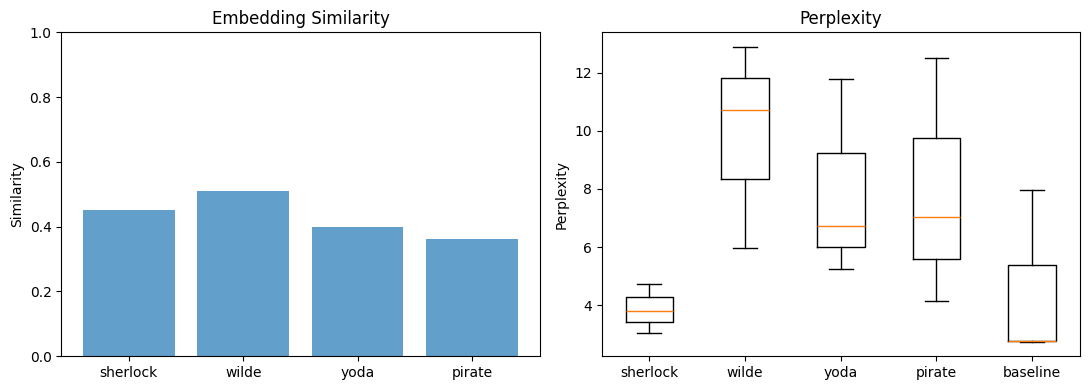

In [26]:
# Plot
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
personas = [k for k in results.keys() if k != 'baseline']
ax[0].bar(personas, [np.mean(results[p]['sim']) for p in personas], alpha=0.7)
ax[0].set_ylabel('Similarity')
ax[0].set_title('Embedding Similarity')
ax[0].set_ylim(0, 1)
ax[1].boxplot([results[p]['ppl'] for p in results.keys()], labels=list(results.keys()))
ax[1].set_ylabel('Perplexity')
ax[1].set_title('Perplexity')
plt.tight_layout()
plt.savefig('eval.png')
plt.show()

## 9. Advanced Features

In [27]:
# Persona blending
class Blender(Steerer):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.active = {}
    def set_blend(self, w, strength=1.0, temp=1.0):
        t = sum(w.values())
        self.active = {k: v/t for k, v in w.items()}
        self.strength, self.temp = strength, temp
        self._resample()
    def _resample(self):
        b = None
        for p, w in self.active.items():
            proto = self.protos[p]
            d = (proto.sample(1, self.temp) - proto.get_mean()).squeeze(0) * w
            b = d if b is None else b + d
        self.v = b
    def _hook_fn(self, m, i, o):
        h = o[0] if isinstance(o, tuple) else o
        t = isinstance(o, tuple)
        if self.v is not None:
            if self.counter % self.every == 0:
                self._resample()
            h[:, -1] += self.v.to(h.device) * self.strength
            self.counter += 1
        return (h,) + o[1:] if t else h

blender = Blender(model, tokenizer, prototypes, target_layer, device)
blender.set_blend({'sherlock': 0.7, 'wilde': 0.3}, strength=1.2)
print(f'70% Sherlock + 30% Wilde: {blender.generate("What is truth?", max_new=40)}')

70% Sherlock + 30% Wilde:  How does it differ from the way we often perceive or use the word "truth" in everyday life?
The concept of "truth" has been a topic of philosophical debate for centuries, and its definition


Set: wilde, strength=1.0, temp=1.0


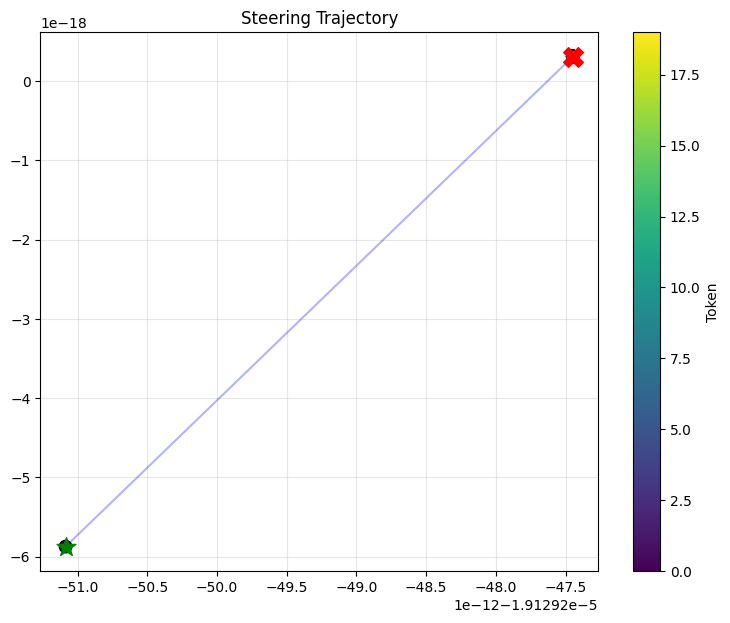

Generated:  Are there any new developments in the field of renewable energy that are worth noting? Yes, there are


In [28]:
# Visualize trajectory
steerer.set_persona('wilde')
out = steerer.generate('Tell me.', max_new=20)
if len(steerer.debug) > 1:
    t = np.array(steerer.debug)
    c = PCA(2).fit_transform(t)
    plt.figure(figsize=(9, 7))
    plt.plot(c[:,0], c[:,1], 'b-', alpha=0.3)
    plt.scatter(c[:,0], c[:,1], c=range(len(c)), cmap='viridis', s=80, edgecolors='black')
    plt.colorbar(label='Token')
    plt.scatter(c[0,0], c[0,1], c='green', s=200, marker='*', zorder=5)
    plt.scatter(c[-1,0], c[-1,1], c='red', s=200, marker='X', zorder=5)
    plt.title('Steering Trajectory')
    plt.grid(True, alpha=0.3)
    plt.savefig('traj.png')
    plt.show()
print(f'Generated: {out}')

In [29]:
# Save
import pickle
with open('results.pkl', 'wb') as f:
    pickle.dump({'prototypes': {k: {'e': v.embs, 'm': v.mean} for k, v in prototypes.items()},
                 'results': results, 'model': MODEL_NAME, 'layer': target_layer}, f)
print('Saved! ✅')

Saved! ✅
